# Bad Honnef Exoplanetary School
## Exoplanets JWST Transmission spectroscopy

In order to perform exoplanet transmission spectroscopy with JWST one requires to obtain time-series spectra of the exoplanet host star.

In this practical exercise, we will now go through an example of obtaining an exoplanet transmission spectrum. As already explained, this is a spectrum of the exoplanet size as a function of wavelength, whose variability depends on the atmospheric constituents and properties of the transiting planet. The observations have already been reduced and the spectra of the exoplanet host star during the transit, as well as the reference stars are saved as pickle files, which you can get from the school's Github repository.

The observations have been made with the [NIRSpec/G395H](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph), [NIRCam/F322W2](https://jwst-docs.stsci.edu/jwst-near-infrared-camera), [NIRISS/SOSS](https://jwst-docs.stsci.edu/jwst-near-infrared-imager-and-slitless-spectrograph) instrument at the JWST as part of the JWST Early Release Science Transiting Exoplanet Community. All three data sets are of one transit of WASP-39b. There's also a transit using NIRSpec/PRISM and MIRI/LRS.

Here are the steps that you are expected to take to obtain the transmission spectrum from these spectra:

1.   Clone the school's [GitHub](https://github.com/bh-atmospheres/summer-schoool-2025/) respository
2.   Read the data using the ${\tt xarray}$ python module, and familiarize yourself with the data structure (dictionaries)
3.   Plot spectra for each dataset
4.   Normalise the spectra
5.   Integrate the spectra over the whole wavelength range to obtain white light curves (WLC), and plot them
6.   Normalize this differential LC by fitting an appropriate polynomial to the out of transit data (Note: Ideally, the out-of-transit polynomial is fitted simultaneously with the transit light curve and any other systematics. )
7.   Model this broadband (white) LC using the analytical transit model of [Mandel & Agol (2002)](https://ui.adsabs.harvard.edu/abs/2002ApJ...580L.171M/abstract), implemented in python (e.g. [${\tt exoplanet}$](https://docs.exoplanet.codes/en/v0.4.3/tutorials/transit/), [${\tt PyTransit}$](https://github.com/hpparvi/PyTransit), [${\tt batman}$](https://lkreidberg.github.io/batman/docs/html/index.html), etc.), obtaining parameter solutions by using MCMC or Nested Sampling to derive posterior distributions (Bayesian Framework).
8.   Obtain narrowband/spectroscopic LCs by integrating the spectra again using spectroscopic bins
9.   Model these LCs, but this time fixing those non-wavelenegth dependant parameters to the results obtained from the broadband LC fit (a/Rs, inc, etc.)
10.  Plot the transmission spectrum, i.e. $R_p/R_\star$ as the function of $\lambda$





In [2]:
# Step 1: cloning the respository
!git clone https://github.com/bh-atmospheres/summer-schoool-2025/
!pip install mpld3 # interactive matplotlib widget

Cloning into 'summer-schoool-2025'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 111 (delta 0), reused 0 (delta 0), pack-reused 87 (from 1)
Receiving objects: 100% (111/111), 119.64 MiB | 26.96 MiB/s, done.
Resolving deltas: 100% (48/48), done.
Updating files: 100% (29/29), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 3.7 MB/s eta 0:00:00


In [1]:
import xarray as xr

In [61]:
# Step 2: reading the data
data = xr.open_dataset('/content/summer-schoool-2025/JWST/WASP-39b/NIRCam_F322W2_Spectra.h5')
data.keys()

time = data['time'].values - data['time'].values[0]

In [11]:
# Step 3: visualizing the data
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import mpld3
from mpld3 import plugins
plt.figure(figsize=(17,6))
plt.errorbar(data['wave_1d'], data['optspec'][0], yerr=data['opterr'][0], lw=1.5)
plt.ylabel('Flux')
plt.xlabel('Wavelength [micron]')
mpld3.display()

In [25]:
# Step 4: Normalise the data
normalised_spectra =  data['optspec']/np.nanmedian(data['optspec'],axis=0)

plt.imshow(normalised_spectra, vmin=0.95, vmax=1.05, aspect='auto')
mpld3.display()

In [46]:
# Step 5: Obtain WLC

WLC = np.nansum(data['optspec'],axis=1)
WLC_err = np.sqrt(np.sum(data['opterr']**2,axis=1))


plt.errorbar(time, WLC, yerr=WLC_err, fmt='.', capsize=4)
mpld3.display()

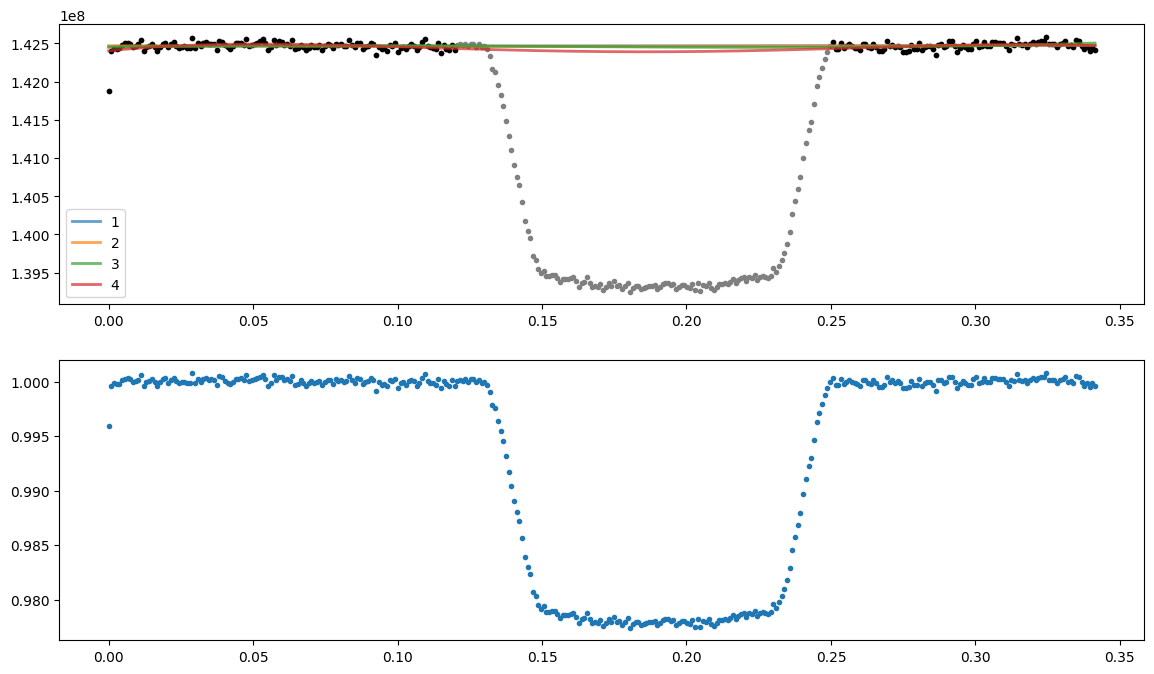

In [70]:
# Step 6: normalizing to out of transit trend (hint: try multiple polynomial orders)
t1        = 0.12        # transit start
t2        = 0.25        # transit end
f_oot     = WLC[np.logical_or(time<t1,time>t2)]
t_oot     = time[np.logical_or(time<t1,time>t2)]
fig, (ax0, ax1) = plt.subplots(2,1, figsize=(14,8))
ax0.plot(time, WLC, 'o', c='grey', ms=3)
ax0.plot(t_oot, f_oot, 'o', c='k', ms=3)
for poly_order in [1,2,3,4]:
  oot_model = np.poly1d(np.polyfit(t_oot, f_oot, poly_order))
  ax0.plot(time, oot_model(time), lw=2, alpha=0.7, label=poly_order)
ax0.legend()
poly_order = 1 # decide on the polynomial order
oot_model  = np.poly1d(np.polyfit(t_oot, f_oot, poly_order))
ax1.plot(time, WLC/oot_model(time), 'o', ms=3)
F  = WLC/oot_model(time)
T  = time
F_err = WLC_err/oot_model(time)

In [52]:
# Step 7: fitting the broadband transit LC with a transit model
!pip install batman-package  # for an analytical model of a transit
!pip install emcee           # for running MCMC
!pip install corner          # for plotting corner plots
!pip install ldtk            # for calculating LD coefficients

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.8 MB/s eta 0:00:00


In [60]:
wavelength = data['wave_1d'].values

# calculate limb darkening coefficients for the star, given the wavelength of observations
from ldtk import LDPSetCreator, BoxcarFilter

filters = [BoxcarFilter('a', wavelength[0]*1e3, wavelength[-1]*1e3)]

sc = LDPSetCreator(datset='visir-lowres', # need to get the infrared version in low-res
                   teff=(6000,   100),
                   logg=(4.582, 0.20),
                      z=(0.030, 0.01),
                     filters=filters)

ps = sc.create_profiles()
cq,eq = ps.coeffs_qd()
print('u1 = %.5f, u2 = %.5f'%(cq[0][0],cq[0][1]))

u1 = 0.14773, u2 = 0.13271


In [81]:
import batman
PER = 4.0552842 # define period as hardcoded
def transit_model_full(theta, t):
  """
  wrapper for defining a transit model with all parameters free
  """
  t0, rp, a, inc, u1, u2 = theta
  params     = batman.TransitParams()
  params.t0  = t0
  params.per = PER
  params.rp  = rp
  params.a   = a
  params.inc = inc
  params.u   = [u1, u2]
  params.limb_dark = "quadratic"
  params.ecc = 0
  params.w   = 90.
  m          = batman.TransitModel(params, t)
  lc         = m.light_curve(params)

  return lc

t_= np.linspace(T[0],T[-1],endpoint=True,num=1000)
plt.figure(figsize=(14,5))
plt.errorbar(T, F, yerr=F_err, fmt='.k', ms=6)
params = [0.190, 0.145, 11.39, 87.737, cq[0][0], cq[0][1]] # initial guess values for the free parameters
plt.plot(t_, transit_model_full(params, t_), lw=2, alpha=0.7, label='Model with initial guess values')
plt.xlabel('Time')
plt.ylabel('Normalized Flux')
plt.legend()
mpld3.display()

## Bayesian parameter estimation

The system characterisation is a parameter estimation problem, where we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties. This model was discussed in the lecture earlier.

We take a [Bayesian](http://en.wikipedia.org/wiki/Bayesian_probability) approach to parameter estimation, where we want to estimate the [posterior probability](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [prior probabilities](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by [Bayes' theorem](http://en.wikipedia.org/wiki/Bayes%27_theorem) as:

$$ P(\theta | D ) = \frac{P(\theta)P(D|\theta)}{P(D)} $$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [likelihood](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [normalising factor](http://en.wikipedia.org/wiki/Marginal_likelihood) that we don't care about during MCMC-based parameter estimation. This is because be work with derivatives (for miminization) and the derivative of a constant is 0.

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead. Taking the logarithm of the Bayesian relation above has the added advantage of converting the division to addition which is much easier to differentiate:

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \textrm{with} \quad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

This is to say that $\log (posterior) = \log(prior) + \log(likelihood)$.  Note that we left out "$-\log P(D)$" since its derivate will be 0.

### The likelihood

Now we need to decide on the form of the likelihood density function. If we can assume [normally distributed](https://en.wikipedia.org/wiki/Normal_distribution) white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function:

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. (I hope that it is clear that the above relation is just the logarithm of the Gaussian function.)


In [85]:
import emcee
# functions for calculating the Bayesian relation
def log_likelihood(theta, t, flux, flux_err):
    t0, rp, a, inc, u1, u2 = theta
    model_flux = transit_model_full(theta, t)
    return -0.5 * np.sum(((flux - model_flux) / flux_err) ** 2)

def log_prior(theta):
  t0, rp, a, inc, u1, u2 = theta
  if not (0.17 < t0  < 0.20 and 0.13 < rp < 0.18 and 6 < a < 14 and 80. < inc < 90. and 0 <= u1 <= 1 and -1 <= u2 <= 1):
      return -np.inf
  ln_prior_u1 = -0.5 * ((u1 - cq[0][0]) / eq[0][0]) ** 2
  ln_prior_u2 = -0.5 * ((u2 - cq[0][1]) / eq[0][1]) ** 2
  return ln_prior_u1 + ln_prior_u2

def log_posterior(theta, t, flux, flux_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, flux, flux_err)

# initializing the walkers
ndim     = len(params)
nwalkers = 18
pos      = [params + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]

# define the sampler and run MCMC
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(T, F, F_err))
sampler.run_mcmc(pos, 10000, progress=True)

100%|██████████| 10000/10000 [03:27<00:00, 48.17it/s]


State([[ 0.19023919  0.14506836 11.48046428 87.89262987  0.14699765  0.13111669]
 [ 0.19022591  0.14513101 11.47403277 87.88640139  0.14712439  0.13209768]
 [ 0.19023185  0.14509861 11.44287095 87.8566786   0.14678567  0.13055215]
 [ 0.19026215  0.14515641 11.4243074  87.83859608  0.14599875  0.13143399]
 [ 0.19023198  0.14502179 11.47898917 87.89228732  0.14668625  0.12974206]
 [ 0.19021552  0.14507007 11.48976958 87.90733327  0.146872    0.13194662]
 [ 0.19022073  0.14512435 11.47683673 87.88890126  0.14694338  0.13168483]
 [ 0.19024058  0.14512385 11.45860945 87.86836548  0.14675561  0.13075239]
 [ 0.19024704  0.14512272 11.47571646 87.88555523  0.14642711  0.13046371]
 [ 0.19023885  0.14511154 11.46364308 87.87535596  0.14605162  0.12987904]
 [ 0.19024276  0.14509389 11.44530068 87.8593057   0.1463958   0.13157682]
 [ 0.19022412  0.14509426 11.45782571 87.86859399  0.14681151  0.13200138]
 [ 0.1902273   0.14512782 11.45268332 87.85943399  0.14689408  0.13031317]
 [ 0.19022445  0.14

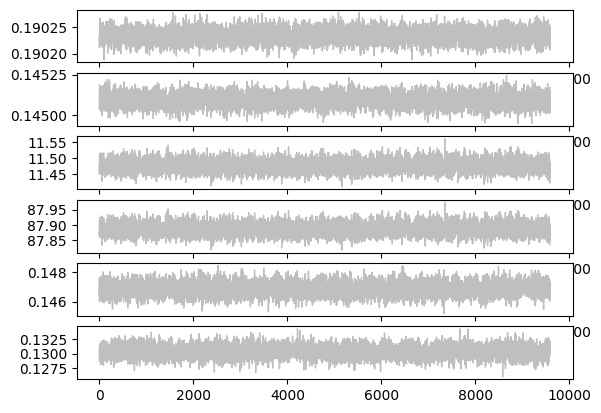

In [86]:
# flatten chains
samples = sampler.get_chain(discard=2000, thin=15, flat=True)
fig, axes = plt.subplots(6,1)
for i,ax in enumerate(axes):
  ax.plot(samples[:,i], lw=1, c='grey', alpha=0.5)

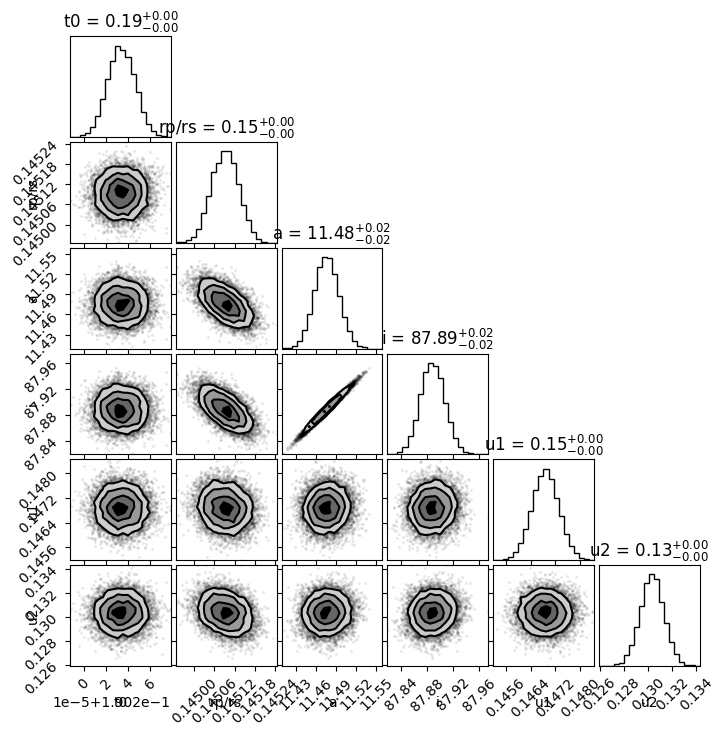

In [87]:
# plot posterior distributions
from corner import corner
fig = corner(samples, labels=["t0", "rp/rs", "a", "i", "u1", "u2"], fill_contours=True, show_titles=True,)
fig.set_size_inches(7,7)
plt.show()

Text(0.5, 0, 'Time from mid-transit [hours]')

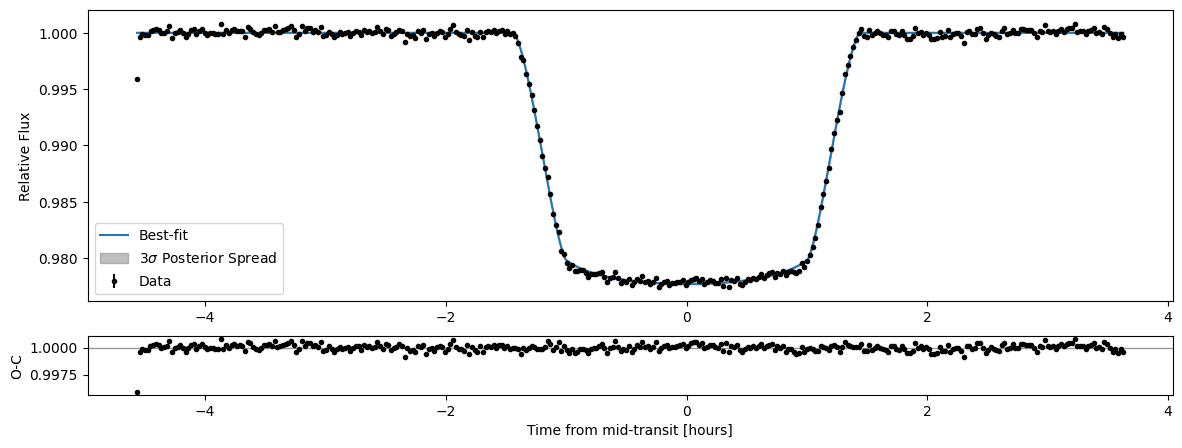

In [91]:
# Plot best-fit model
best_fit_w = np.median(samples, axis=0)
t0, rp, a, inc, u1, u2 = best_fit_w
best_flux  = transit_model_full(best_fit_w, t_)

fig, (ax0, ax1) = plt.subplots(2,1,figsize=(14,5),height_ratios=[5,1])
ax0.errorbar(24*(T-t0), F, yerr=F_err, fmt=".k", label="Data")
ax0.plot(24*(t_-t0), best_flux, "C0", label="Best-fit")

# optional: draw random results from the samples to obtain model uncertainties, for visual purposes.
draw     = np.floor(np.random.uniform(0,len(samples),size=1000)).astype(int)
thetas   = samples[draw]
models   = []
for i in thetas:
  t0, rp, a, inc, u1, u2 = i
  models.append(transit_model_full(i, t_))
spread = np.std(models,axis=0)
#med_model = np.median(models,axis=0)

ax0.fill_between(24*(t_-t0),best_flux-3*spread,best_flux+3*spread,color='grey',alpha=0.5,label=r'$3\sigma$ Posterior Spread')
ax0.set_ylabel("Relative Flux")
ax0.legend()
# calculate residuals of the model
residuals  = F / transit_model_full(best_fit_w, time)
ax1.axhline(1.0, lw=1, c='grey', alpha=0.8)
ax1.plot(24*(time-t0), residuals, ".k", label="Residuals")
ax1.set_ylabel("O-C")
ax1.set_xlabel("Time from mid-transit [hours]")

Processing the bin centered on 2.4546018123626707
2.404601812362671 2.504601812362671


100%|██████████| 5000/5000 [00:06<00:00, 738.98it/s]


Processing the bin centered on 2.554601716995239
2.5046017169952393 2.6046017169952393


100%|██████████| 5000/5000 [00:06<00:00, 753.14it/s]


Processing the bin centered on 2.6546016216278074
2.6046016216278076 2.7046016216278077


...

100%|██████████| 5000/5000 [00:06<00:00, 803.68it/s]


Processing the bin centered on 3.954600381851196
3.9046003818511963 4.004600381851196


100%|██████████| 5000/5000 [00:07<00:00, 704.31it/s]


Processing the bin centered on 4.0546002864837645
4.004600286483765 4.104600286483764


100%|██████████| 5000/5000 [00:06<00:00, 807.43it/s]


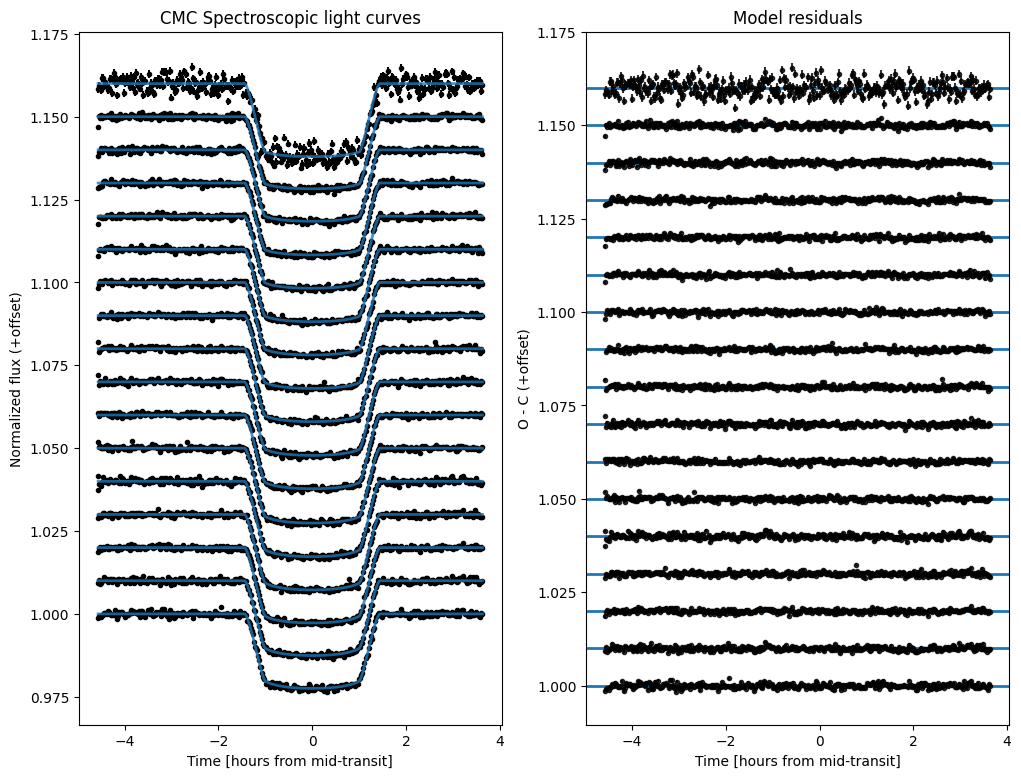

In [149]:
# Steps 8, 9 & 10: Obtain spectral LCs, remove common mode residuals and model them, fitting only wavelength-dependent parameters

step=0.1 # micron

def transit_model_spec(theta, t):

  rp, u1, u2 = theta
  params           = batman.TransitParams()
  params.t0        = best_fit_w[0]
  params.per       = PER
  params.rp        = rp
  params.a         = best_fit_w[2]
  params.inc       = best_fit_w[3]
  params.u         = [u1, u2]
  params.limb_dark = "quadratic"
  params.ecc       = 0.
  params.w         = 90.
  m                = batman.TransitModel(params, t)
  lc               = m.light_curve(params)

  return lc

offset = 0.
TS     = []
fig, (ax0, ax1) = plt.subplots(1,2, figsize=(12,9))
ax0.set_ylabel('Normalized flux (+offset)')
ax1.set_ylabel('O - C (+offset)')
ax0.set_xlabel('Time [hours from mid-transit]')
ax1.set_xlabel('Time [hours from mid-transit]')
ax0.set_title('CMC Spectroscopic light curves')
ax1.set_title('Model residuals')
for x1 in np.arange(wavelength[0],wavelength[-1],step=step):
  print('Processing the bin centered on '+str(x1+step/2))
  x2  = x1 + step

  wvl_start_pixel = np.where(wavelength >= x1)[0][0]
  wvl_end_pixel = np.where(wavelength <= x2)[0][-1]
  LC = np.nansum(data['optspec'][:,wvl_start_pixel:wvl_end_pixel],axis=1)

  e_LC      = np.sqrt(np.nansum(data['opterr'][:,wvl_start_pixel:wvl_end_pixel]**2,axis=1))

  f_oot     = LC[np.logical_or(time<t1,time>t2)]
  oot_model = np.poly1d(np.polyfit(t_oot, f_oot, poly_order)) # using the same order polynomial as white LC
  F_        = LC/oot_model(time)
  F_err_    = e_LC/oot_model(time)

  # calculate limb darkening coefficients for the wavelengths of each bin
  print(x1, x2)
  filter = [BoxcarFilter('a', x1*1e3, x2*1e3)]

  sc = LDPSetCreator(dataset='visir-lowres',
                     teff=(6000,   50),
                     logg=(4.582, 0.20),
                        z=(0.030, 0.01),
                      filters=filter)

  ps = sc.create_profiles()
  cq,eq = ps.coeffs_qd()

  # redefine Bayesian relation
  def log_likelihood(theta, t, flux, flux_err):
      rp, u1, u2 = theta
      model_flux = transit_model_spec(theta, t)
      return -0.5 * np.sum(((flux - model_flux) / flux_err) ** 2)

  def log_prior(theta):
    rp, u1, u2 = theta
    if not (0.13 < rp < 0.18 and 0 <= u1 <= 1 and -1 <= u2 <= 1):
        return -np.inf
    ln_prior_u1 = -0.5 * ((u1 - cq[0][0]) / (3*eq[0][0])) ** 2
    ln_prior_u2 = -0.5 * ((u2 - cq[0][1]) / (3*eq[0][1])) ** 2
    return ln_prior_u1 + ln_prior_u2

  def log_posterior(theta, t, flux, flux_err):
      lp = log_prior(theta)
      if not np.isfinite(lp):
          return -np.inf
      return lp + log_likelihood(theta, t, flux, flux_err)

  # parameter starting point & walker initiation
  initial    = [best_fit_w[1], cq[0][0], cq[0][1]]
  ndim       = len(initial)
  nwalkers   = 9
  pos        = [initial + 1e-5*np.random.randn(ndim) for i in range(nwalkers)]

  # run sampler
  sampler    = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(time, F_, F_err_))
  sampler.run_mcmc(pos, 5000, progress=True)

  # flatten the chains to get the samples
  samples = sampler.get_chain(discard=2000, thin=15, flat=True)

  # obtain best fit parameters
  best_fit_s = np.median(samples, axis=0)
  rp, u1, u2 = best_fit_s
  best_flux  = transit_model_spec(best_fit_s, t_)

  # plot spectroscopic light curves, together with best fit models
  ax0.errorbar(24*(time-t0), F_+offset, yerr=F_err_, fmt=".k", zorder=1)
  ax0.plot(24*(t_-t0), best_flux+offset, c="C0", lw=2, alpha=0.8, zorder=2)

  # plot the residuals of each fit
  ax1.errorbar(24*(time-t0), F_-transit_model_spec(best_fit_s, time)+1.+offset, yerr=F_err_, fmt=".k", zorder=2, alpha=0.8)
  ax1.axhline(1.+offset, c="C0", lw=2, zorder=1)

  offset += 0.01

  # store bin information and planet radius results, together with their errors into an array
  TS.append(np.array([float(x1+step),rp,np.percentile(samples,16,axis=0)[0]-rp,np.percentile(samples,84,axis=0)[0]-rp,np.std(samples,axis=0)[0]]))


Text(0.5, 0, 'Wavelength [micron]')

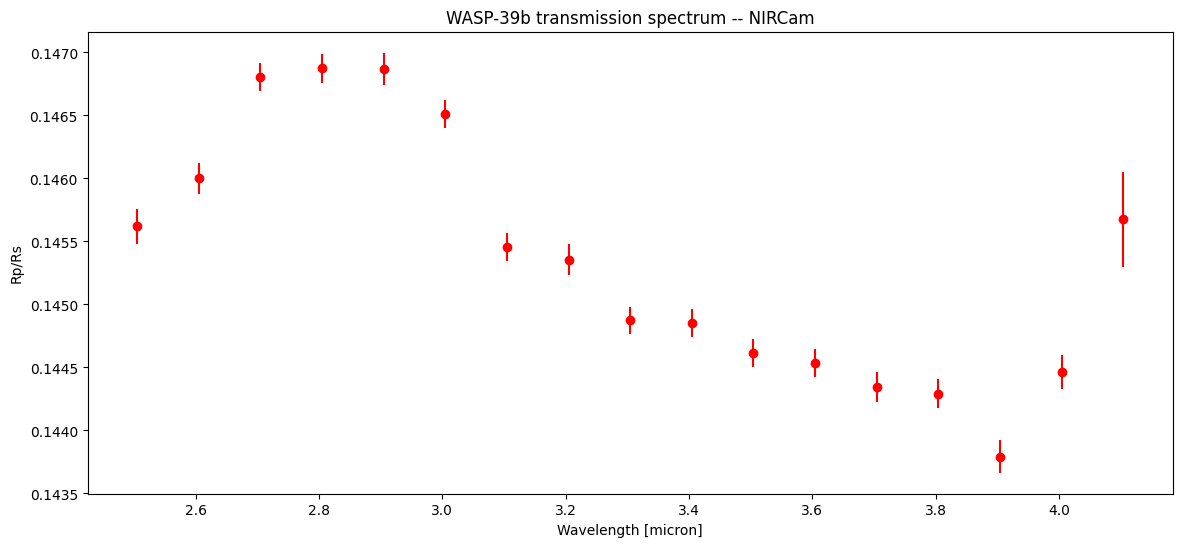

In [150]:
# Step 11: Obtain and plot the transmission spectrum
TS = np.array(TS)
plt.figure(figsize=(14,6))
plt.title('WASP-39b transmission spectrum -- NIRCam')
plt.plot(TS[:,0], TS[:,1], '.', ms=3)
plt.errorbar(TS[:,0], TS[:,1], yerr=TS[:,4], fmt='o', c='red')
plt.ylabel('Rp/Rs')
plt.xlabel('Wavelength [micron]')